In [107]:
import numpy as np;
import torch;
import torchvision;
import torch.nn as nn;
from torch.utils.data import DataLoader, Dataset, random_split;
import torchvision.transforms as transforms;
import os;
from PIL import Image;
import matplotlib.pyplot as plt;

In [77]:
class FER2013(Dataset):
    def __init__(self, root_path="", transform=None):
        self.classes = os.listdir(root_path);
        self.images_path = [];
        self.labels = [];
        for i, cls in enumerate(self.classes):
            class_path = os.path.join(root_path, cls);
            self.images_path += [os.path.join(class_path, image_name) for image_name in os.listdir(class_path)];
            self.labels += [i for _ in range(len(os.listdir(class_path)))]
        self.transform = transform;

    def __getitem__(self, idx):
        image = Image.open(self.images_path[idx]);
        label = self.labels[idx];
        if transform:
            image = self.transform(image);
        return image, label;

    def __len__(self):
        return len(self.labels);

In [78]:
train_root_path = r"D:\AI\machine_learning\code\datasets\FER2013\train";
test_root_path = r"D:\AI\machine_learning\code\datasets\FER2013\test";

In [79]:
transform = transforms.ToTensor();

In [91]:
full_train_dataset = FER2013(train_root_path, transform=transform);
test_dataset = FER2013(test_root_path, transform=transform);

In [92]:
train_size = int(0.8*len(full_train_dataset));
val_size = len(full_train_dataset) - train_size;
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size]);

In [93]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True);
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True);
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True);

In [104]:
next(iter(train_loader))[0].shape

torch.Size([64, 1, 48, 48])

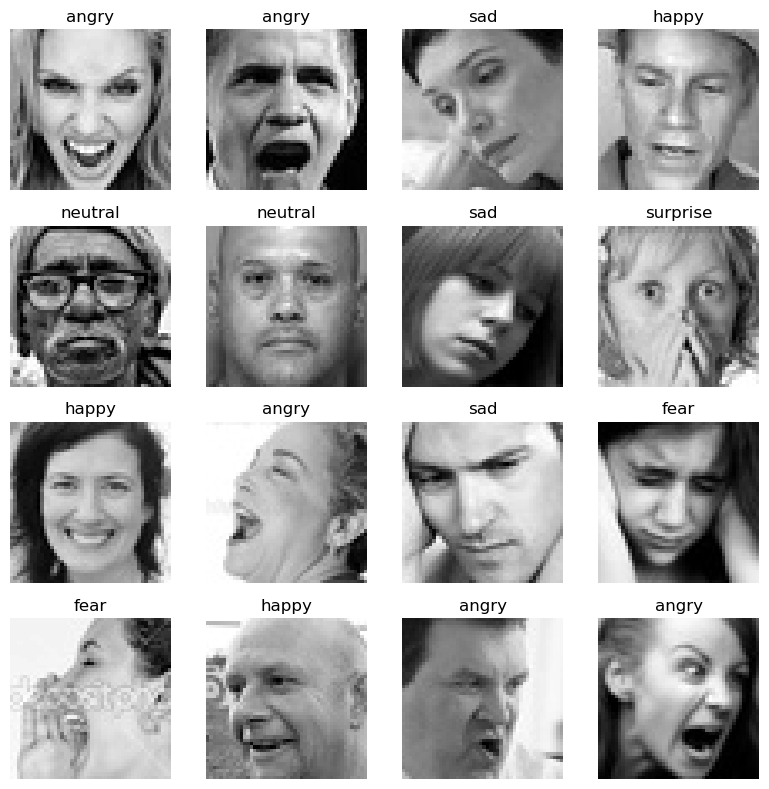

In [114]:
l = len(full_train_dataset);
indices = np.random.choice(l, 16, replace=False)

fig, axs = plt.subplots(4,4, figsize=(8,8));

for i in range(16):
    idx = indices[i];
    image, label = full_train_dataset[idx];
    r,c = divmod(i, 4);
    axs[r,c].imshow(image.squeeze().numpy(), 'gray');
    axs[r,c].set_title(full_train_dataset.classes[full_train_dataset.labels[idx]]);
    axs[r,c].axis('off');

plt.tight_layout();
plt.show();

In [121]:
train_dataset[0][0].shape

torch.Size([1, 48, 48])